Loading required package: car

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘car’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData



 기술통계
당뇨 그룹    | n = 270 | Mean = 35.29 | SD = 6.64
비당뇨 그룹  | n = 492 | Mean = 30.87 | SD = 6.56

 1. Shapiro-Wilk 정규성 검정
당뇨 그룹    | W = 0.9491 | p-value = 0.0000  →  정규성 불만족 (비정규)
비당뇨 그룹  | W = 0.9807 | p-value = 0.0000  →  정규성 불만족 (비정규)

 2. Levene's Test 등분산성 검정
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   1  1.4004  0.237
      760               
→ p-value = 0.2370  |  등분산 (var.equal = TRUE)

 3. Welch's t-test (등분산 미가정)

	Welch Two Sample t-test

data:  bmi_diabetic and bmi_nondiabetic
t = 8.8234, df = 548.05, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 3.433974 5.400813
sample estimates:
mean of x mean of y 
  35.2863   30.8689 


 4. Student's t-test (등분산 가정)

	Two Sample t-test

data:  bmi_diabetic and bmi_nondiabetic
t = 8.8554, df = 760, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 3.

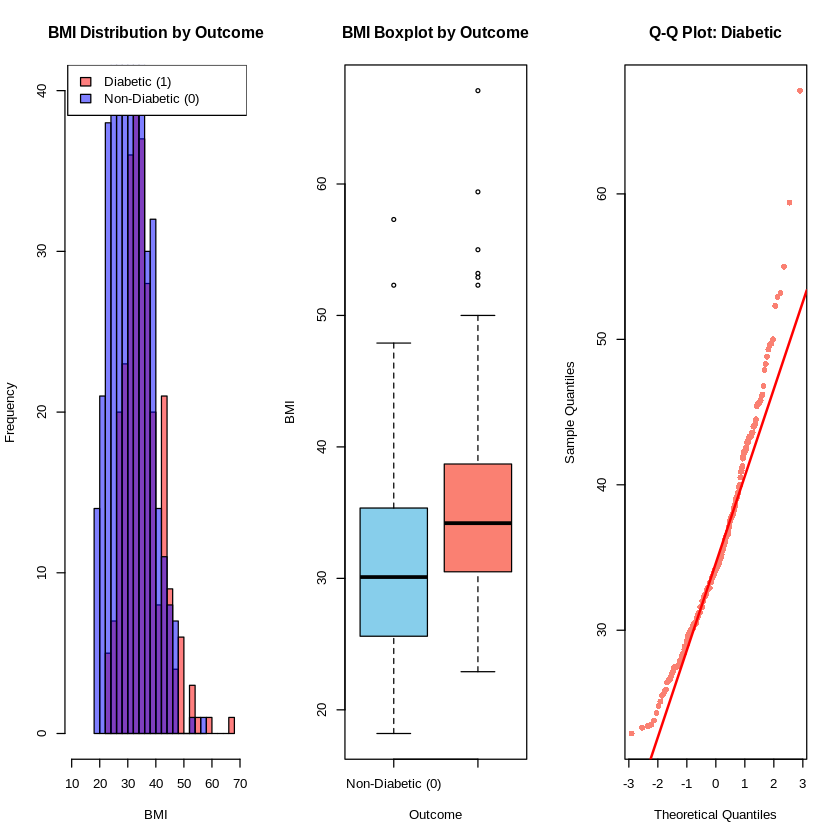

In [1]:
# ============================================================
# 당뇨병 유무에 따른 BMI 차이 검정
# Ho: 당뇨인과 당뇨 아닌 사람의 평균 BMI는 차이가 없다
# H1: 당뇨인과 당뇨 아닌 사람의 평균 BMI는 차이가 있다
# ============================================================

# 패키지 설치 및 로드
if (!require("car")) install.packages("car")
library(car)

# ── 데이터 로드 ──────────────────────────────────────────────
df <- read.table("/content/Diabetes_exdata.txt", header = TRUE, sep = "\t")

# BMI 결측치 제거 후 그룹 분리
df_clean <- df[!is.na(df$BMI), ]
bmi_diabetic     <- df_clean$BMI[df_clean$Outcome == 1]
bmi_nondiabetic  <- df_clean$BMI[df_clean$Outcome == 0]

cat("==========================================================\n")
cat(" 기술통계\n")
cat("==========================================================\n")
cat(sprintf("당뇨 그룹    | n = %d | Mean = %.2f | SD = %.2f\n",
            length(bmi_diabetic), mean(bmi_diabetic), sd(bmi_diabetic)))
cat(sprintf("비당뇨 그룹  | n = %d | Mean = %.2f | SD = %.2f\n",
            length(bmi_nondiabetic), mean(bmi_nondiabetic), sd(bmi_nondiabetic)))

# ── 1. 정규성 검정 (Shapiro-Wilk) ────────────────────────────
cat("\n==========================================================\n")
cat(" 1. Shapiro-Wilk 정규성 검정\n")
cat("==========================================================\n")
sw_diabetic    <- shapiro.test(bmi_diabetic)
sw_nondiabetic <- shapiro.test(bmi_nondiabetic)

cat(sprintf("당뇨 그룹    | W = %.4f | p-value = %.4f  →  %s\n",
            sw_diabetic$statistic, sw_diabetic$p.value,
            ifelse(sw_diabetic$p.value < 0.05, "정규성 불만족 (비정규)", "정규성 만족")))
cat(sprintf("비당뇨 그룹  | W = %.4f | p-value = %.4f  →  %s\n",
            sw_nondiabetic$statistic, sw_nondiabetic$p.value,
            ifelse(sw_nondiabetic$p.value < 0.05, "정규성 불만족 (비정규)", "정규성 만족")))

normality_pass <- sw_diabetic$p.value >= 0.05 & sw_nondiabetic$p.value >= 0.05

# ── 2. 등분산성 검정 (Levene's Test) ─────────────────────────
cat("\n==========================================================\n")
cat(" 2. Levene's Test 등분산성 검정\n")
cat("==========================================================\n")
levene_result <- leveneTest(BMI ~ as.factor(Outcome), data = df_clean)
print(levene_result)
levene_pval <- levene_result$`Pr(>F)`[1]
equal_var <- levene_pval >= 0.05
cat(sprintf("→ p-value = %.4f  |  %s\n", levene_pval,
            ifelse(equal_var, "등분산 (var.equal = TRUE)", "이분산 (var.equal = FALSE)")))

# ── 3. Welch's t-test (정규성 & 이분산 가정) ─────────────────
cat("\n==========================================================\n")
cat(" 3. Welch's t-test (등분산 미가정)\n")
cat("==========================================================\n")
welch_result <- t.test(bmi_diabetic, bmi_nondiabetic, var.equal = FALSE)
print(welch_result)

# ── 4. Student's t-test (정규성 & 등분산 가정) ───────────────
cat("\n==========================================================\n")
cat(" 4. Student's t-test (등분산 가정)\n")
cat("==========================================================\n")
student_result <- t.test(bmi_diabetic, bmi_nondiabetic, var.equal = TRUE)
print(student_result)

# ── 5. Wilcoxon rank-sum test (비모수) ───────────────────────
cat("\n==========================================================\n")
cat(" 5. Wilcoxon Rank-Sum Test (Mann-Whitney U test)\n")
cat("==========================================================\n")
wilcox_result <- wilcox.test(bmi_diabetic, bmi_nondiabetic, alternative = "two.sided")
print(wilcox_result)

# ── 6. 최종 해석 요약 ────────────────────────────────────────
cat("\n==========================================================\n")
cat(" 최종 해석 요약\n")
cat("==========================================================\n")
cat(sprintf("정규성 검정  : %s\n", ifelse(normality_pass, "두 그룹 모두 정규성 만족", "정규성 불만족 → 비모수 권장")))
cat(sprintf("등분산 검정  : %s\n", ifelse(equal_var, "등분산", "이분산")))
cat(sprintf("Welch t-test : p = %.4f → %s\n", welch_result$p.value,
            ifelse(welch_result$p.value < 0.05, "H1 채택 (유의한 차이 있음)", "H0 채택 (유의한 차이 없음)")))
cat(sprintf("Student t-test: p = %.4f → %s\n", student_result$p.value,
            ifelse(student_result$p.value < 0.05, "H1 채택 (유의한 차이 있음)", "H0 채택 (유의한 차이 없음)")))
cat(sprintf("Wilcoxon test: p = %.4f → %s\n", wilcox_result$p.value,
            ifelse(wilcox_result$p.value < 0.05, "H1 채택 (유의한 차이 있음)", "H0 채택 (유의한 차이 없음)")))

# ── 7. 데이터 분포 시각화 ────────────────────────────────────
par(mfrow = c(1, 3))

# Histogram
hist(bmi_diabetic, col = rgb(1,0,0,0.5), main = "BMI Distribution by Outcome",
     xlab = "BMI", ylab = "Frequency", xlim = c(10, 70), breaks = 20)
hist(bmi_nondiabetic, col = rgb(0,0,1,0.5), add = TRUE, breaks = 20)
legend("topright", legend = c("Diabetic (1)", "Non-Diabetic (0)"),
       fill = c(rgb(1,0,0,0.5), rgb(0,0,1,0.5)))

# Boxplot
boxplot(BMI ~ Outcome, data = df_clean,
        col = c("skyblue", "salmon"),
        names = c("Non-Diabetic (0)", "Diabetic (1)"),
        main = "BMI Boxplot by Outcome",
        ylab = "BMI")

# Q-Q Plot
qqnorm(bmi_diabetic, main = "Q-Q Plot: Diabetic", col = "salmon", pch = 16)
qqline(bmi_diabetic, col = "red", lwd = 2)

par(mfrow = c(1, 1))